In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dfB=pd.read_csv('Bozeman_limpio_final.csv')
dfB.head()


,Unnamed: 0.1,Unnamed: 0,last_scraped,source,name,description,host_name,host_since,host_location,host_about,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,reviews_per_month
0,0,0,09/11/2024,city scrape,Unique neighborhood cottage,"Not for everyone, but loved by many'<br />' Th...",Stacie,29/05/2012,"Bozeman, MT",I love my home and love sharing it.,...,1.0,4.95,4.95,4.97,4.99,4.98,4.98,4.89,1.0,1.72
1,1,1,09/11/2024,city scrape,Downtown Bozeman Vacation Rental,Just four easy blocks from historic downtown B...,Brian,08/11/2013,"Bozeman, MT",I'm a born and raised Montanan. I've done some...,...,5.0,4.97,4.98,4.95,4.97,4.99,4.93,4.94,2.0,3.92
2,2,2,09/11/2024,city scrape,Northside Hideaway,"Free, fast Wi-Fi for remote learning/working n...",Paul,17/08/2013,"Bozeman, MT",I started Bozeman Cottage Vacation Rentals in ...,...,1.0,4.76,4.89,4.82,4.95,4.97,4.97,4.70,3.0,0.30
3,3,3,09/11/2024,city scrape,2 Blocks 2 Main,This space is designed for 1-2 people that wan...,Irene,31/07/2013,"Bozeman, MT",I have lived in or near Bozeman all of my life...,...,0.0,4.96,5.00,5.00,5.00,4.98,5.00,4.73,2.0,0.47
4,4,4,09/11/2024,city scrape,Modern Home Near Campus & Downtown,"Great house on the south side of town, near ca...",Kris And Alex,20/08/2013,"Livingston, MT",We have been traveling with Airbnb for the pas...,...,2.0,4.77,4.87,4.90,4.91,4.83,4.89,4.73,1.0,2.46


In [4]:
#dfB=dfB.drop('Unnamed: 0',axis=1)
dfB=dfB.drop( 'Unnamed: 0.1',axis=1)
dfB.head()
dfB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0       last_scraped                567 non-null    object 
 1   source                          567 non-null    object 
 2   name                            567 non-null    object 
 3   description                     567 non-null    object 
 4   host_name                       567 non-null    object 
 5   host_since                      567 non-null    object 
 6   host_location                   567 non-null    object 
 7   host_about                      567 non-null    object 
 8   host_response_time              567 non-null    object 
 9   host_response_rate              567 non-null    object 
 10  host_acceptance_rate            567 non-null    float64
 11  host_is_superhost               567 non-null    object 
 12  host_verifications              567 

In [5]:
hotel_room_dfB = dfB[dfB['room_type'] == 'Hotel room']
entire_home_dfB = dfB[dfB['room_type'] == 'Entire home/apt']
private_room_dfB = dfB[dfB['room_type'] == 'Private room']
shared_room_dfB = dfB[dfB['room_type'] == 'Shared room'] 

In [6]:
#eliminamos colunas que no nos interesan
hotel_room_dfB.drop(hotel_room_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
entire_home_dfB.drop(entire_home_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
private_room_dfB.drop(private_room_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
shared_room_dfB.drop(shared_room_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)

C:\Users\jesus\AppData\Local\Temp\ipykernel_23160\3393999898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_room_dfB.drop(hotel_room_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
C:\Users\jesus\AppData\Local\Temp\ipykernel_23160\3393999898.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entire_home_dfB.drop(entire_home_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
C:\Users\jesus\AppData\Local\Temp\ipykernel_23160\3393999898.py:4: Set

In [7]:
hotel_room_dfB['instant_bookable'] = hotel_room_dfB['instant_bookable'] == 't'



C:\Users\jesus\AppData\Local\Temp\ipykernel_23160\3210486753.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_room_dfB['instant_bookable'] = hotel_room_dfB['instant_bookable'] == 't'


In [8]:
Vars_Indep_hotel_room = hotel_room_dfB[['instant_bookable']]  
Var_Dep_hotel_room = hotel_room_dfB['price']

<Axes: xlabel='instant_bookable', ylabel='price'>

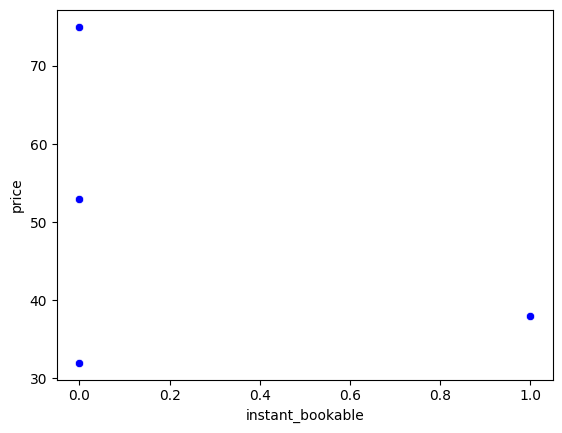

In [9]:
from turtle import color   
sns.scatterplot(x='instant_bookable',y='price',color='blue',data=hotel_room_dfB)

In [10]:

#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [11]:
type(model)

sklearn.linear_model._base.LinearRegression

In [12]:
model.fit(X=Vars_Indep_hotel_room, y=Var_Dep_hotel_room)

LinearRegression()

In [13]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['instant_bookable'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-15.33333333]),
 'rank_': 1,
 'singular_': array([0.8660254]),
 'intercept_': np.float64(53.333333333333336)}

In [14]:
model.score(Vars_Indep_hotel_room,Var_Dep_hotel_room)


0.16015743263699667

In [15]:
y_pred_hotel_room=model.predict(X=hotel_room_dfB[['instant_bookable']])
y_pred_hotel_room

array([53.33333333, 53.33333333, 38.        , 53.33333333])

In [16]:
hotel_room_dfB.insert(0,'predicciones_hotel_room',y_pred_hotel_room)
hotel_room_dfB

,predicciones_hotel_room,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,price,instant_bookable,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
27,53.333333,0.99,f,t,Room in hostel,Hotel room,32.0,False,5.0,6.0,2.5,1,4.9,4.80,3.26
28,53.333333,0.99,f,t,Room in hostel,Hotel room,53.0,False,5.0,1.0,2.5,1,4.9,4.74,2.21
30,38.000000,0.99,f,t,Room in hostel,Hotel room,38.0,True,5.0,4.0,2.5,1,4.9,4.90,2.17
35,53.333333,0.99,f,t,Room in hostel,Hotel room,75.0,False,5.0,2.0,2.5,1,4.9,4.90,1.45


<Axes: xlabel='instant_bookable', ylabel='price'>

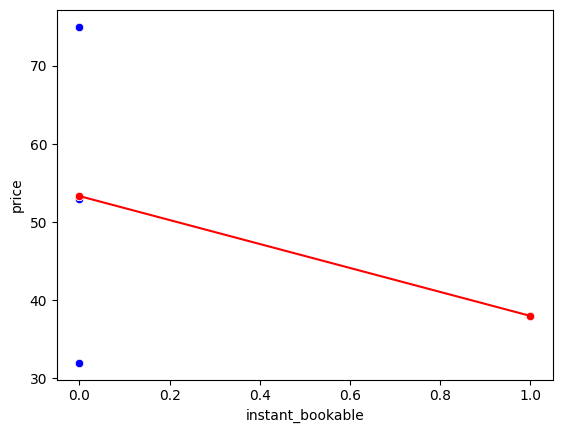

In [17]:
sns.scatterplot(x='instant_bookable',y='price',color='blue',data=hotel_room_dfB)
sns.scatterplot(x='instant_bookable',y='predicciones_hotel_room',color='red',data=hotel_room_dfB)
sns.lineplot(x='instant_bookable',y='predicciones_hotel_room',color='red',data=hotel_room_dfB)

In [18]:
coef_Deter_hotel_room=model.score(X=Vars_Indep_hotel_room, y=Var_Dep_hotel_room)
coef_Deter_hotel_room

0.16015743263699667

In [19]:
coef_Correl_hotel_room=np.sqrt(coef_Deter_hotel_room)
coef_Correl_hotel_room

np.float64(0.4001967424117751)

In [ ]:
#hotel_room_dfB.host_is_superhost = hotel_room_dfB.host_response_rate.replace({'09/11/2024':'49.5'}, regex=False)

C:\Users\jesus\AppData\Local\Temp\ipykernel_1360\665962708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_room_dfB.host_response_rate = hotel_room_dfB.host_response_rate.replace({'09/11/2024':'49.5'}, regex=False)


In [20]:
import numpy as np

numeric_df_hotel_room = hotel_room_dfB.select_dtypes(include=[np.number])
Corr_Factors_hotel_room = numeric_df_hotel_room.corr()
print(Corr_Factors_hotel_room)

                           predicciones_hotel_room  host_acceptance_rate  \
predicciones_hotel_room                   1.000000                   NaN   
host_acceptance_rate                           NaN                   NaN   
price                                     0.400197                   NaN   
host_total_listings_count                      NaN                   NaN   
accommodates                             -0.225494                   NaN   
bathrooms                                      NaN                   NaN   
bedrooms                                       NaN                   NaN   
review_scores_cleanliness                      NaN                   NaN   
review_scores_value                      -0.548860                   NaN   
reviews_per_month                         0.091695                   NaN   

                              price  host_total_listings_count  accommodates  \
predicciones_hotel_room    0.400197                        NaN     -0.225494   
hos

In [21]:
Corr_Factors_hotel_room1=abs(Corr_Factors_hotel_room)
Corr_Factors_hotel_room1

,predicciones_hotel_room,host_acceptance_rate,price,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
predicciones_hotel_room,1.000000,NaN,0.400197,NaN,0.225494,NaN,NaN,NaN,0.548860,0.091695
host_acceptance_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,0.400197,NaN,1.000000,NaN,0.757247,NaN,NaN,NaN,0.262260,0.870782
host_total_listings_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,0.225494,NaN,0.757247,NaN,1.000000,NaN,NaN,NaN,0.161846,0.768063
bathrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_cleanliness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_value,0.548860,NaN,0.262260,NaN,0.161846,NaN,NaN,NaN,1.000000,0.502806
reviews_per_month,0.091695,NaN,0.870782,NaN,0.768063,NaN,NaN,NaN,0.502806,1.000000


<Axes: >

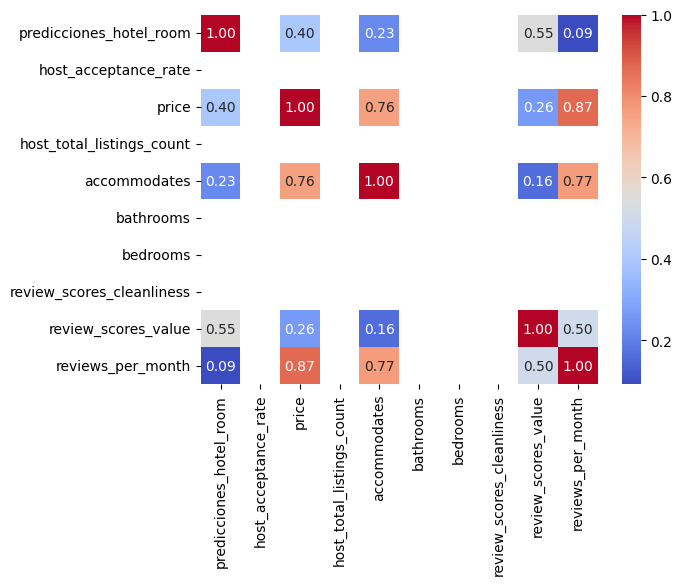

In [22]:
Heat_map=sns.heatmap(Corr_Factors_hotel_room1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map

<Axes: xlabel='instant_bookable', ylabel='price'>

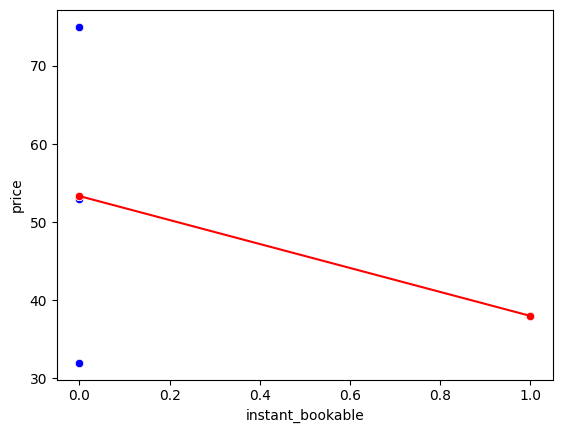

In [23]:

sns.scatterplot(x='instant_bookable',y='price',color="blue",data=hotel_room_dfB)
sns.scatterplot(x='instant_bookable',y='predicciones_hotel_room',color="red",data=hotel_room_dfB)
sns.lineplot(x='instant_bookable',y='predicciones_hotel_room',color="red",data=hotel_room_dfB)


 ENTIRE HOME 

In [24]:
entire_home_dfB['instant_bookable'] = entire_home_dfB['instant_bookable'].map({'t': 1, 'f': 0})


C:\Users\jesus\AppData\Local\Temp\ipykernel_23160\1830598168.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entire_home_dfB['instant_bookable'] = entire_home_dfB['instant_bookable'].map({'t': 1, 'f': 0})


In [25]:
Vars_Indep_entire_home = entire_home_dfB[['instant_bookable']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_entire_home = entire_home_dfB['price']

In [26]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [27]:
type(model)

sklearn.linear_model._base.LinearRegression

In [28]:
model.fit(X=Vars_Indep_entire_home, y=Var_Dep_entire_home)

LinearRegression()

In [32]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['instant_bookable'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1.10512579]),
 'rank_': 1,
 'singular_': array([11.36829342]),
 'intercept_': np.float64(206.09137969269761)}

In [33]:
model.score(Vars_Indep_entire_home,Var_Dep_entire_home)

1.6266261517960956e-05

In [35]:
y_pred_entire_home=model.predict(X=entire_home_dfB[['instant_bookable']])
y_pred_entire_home

array([206.09137969, 206.09137969, 206.09137969, 207.19650549,
       206.09137969, 206.09137969, 206.09137969, 206.09137969,
       206.09137969, 206.09137969, 206.09137969, 206.09137969,
       206.09137969, 206.09137969, 206.09137969, 207.19650549,
       207.19650549, 207.19650549, 206.09137969, 207.19650549,
       207.19650549, 206.09137969, 207.19650549, 207.19650549,
       207.19650549, 206.09137969, 206.09137969, 206.09137969,
       206.09137969, 207.19650549, 206.09137969, 206.09137969,
       206.09137969, 206.09137969, 206.09137969, 207.19650549,
       207.19650549, 206.09137969, 206.09137969, 206.09137969,
       207.19650549, 206.09137969, 207.19650549, 206.09137969,
       207.19650549, 206.09137969, 207.19650549, 206.09137969,
       207.19650549, 206.09137969, 207.19650549, 206.09137969,
       206.09137969, 207.19650549, 206.09137969, 206.09137969,
       206.09137969, 206.09137969, 207.19650549, 206.09137969,
       207.19650549, 207.19650549, 206.09137969, 206.09

In [36]:
entire_home_dfB.insert(0,'predicciones_entire_home',y_pred_entire_home)
entire_home_dfB


,predicciones_entire_home,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,price,instant_bookable,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
0,206.091380,0.92,f,t,Entire home,Entire home/apt,150.0,0,1.0,2.0,2.0,2,4.97,4.89,1.72
1,206.091380,1.00,t,t,Entire guesthouse,Entire home/apt,135.0,0,2.0,2.0,1.0,1,4.95,4.94,3.92
2,206.091380,0.99,t,t,Entire home,Entire home/apt,167.0,0,38.0,4.0,1.5,1,4.82,4.70,0.30
3,207.196505,0.92,t,f,Entire rental unit,Entire home/apt,175.0,1,2.0,2.0,1.0,1,5.00,4.73,0.47
4,206.091380,1.00,t,t,Entire home,Entire home/apt,255.0,0,2.0,6.0,2.0,3,4.90,4.73,2.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,206.091380,0.95,f,t,Entire rental unit,Entire home/apt,148.0,0,1.0,4.0,2.0,2,4.90,4.80,2.10
563,206.091380,1.00,t,t,Entire home,Entire home/apt,840.0,0,10.0,2.0,2.0,1,4.90,4.80,2.10
564,207.196505,0.99,t,t,Entire rental unit,Entire home/apt,82.0,1,17.0,2.0,1.5,1,4.90,4.80,2.10
565,207.196505,1.00,t,t,Entire home,Entire home/apt,1092.0,1,10.0,8.0,1.6,4,4.90,4.80,2.10


<Axes: xlabel='instant_bookable', ylabel='price'>

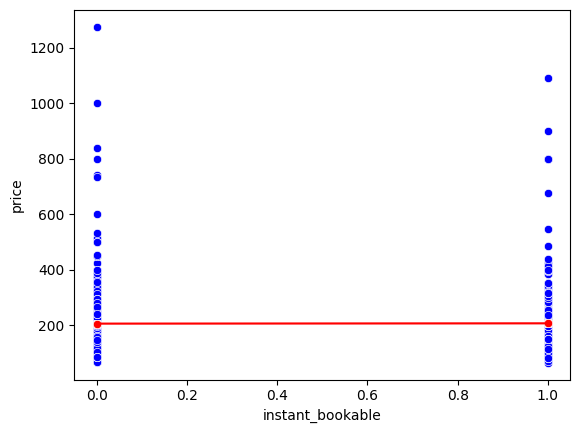

In [37]:

sns.scatterplot(x='instant_bookable',y='price',color="blue",data=entire_home_dfB)
sns.scatterplot(x='instant_bookable',y='predicciones_entire_home',color="red",data=entire_home_dfB)
sns.lineplot(x='instant_bookable',y='predicciones_entire_home',color="red",data=entire_home_dfB)

In [38]:
coef_Deter_entire_home=model.score(X=Vars_Indep_entire_home, y=Var_Dep_entire_home)
coef_Deter_entire_home

1.6266261517960956e-05

In [39]:
coef_Correl_entire_home=np.sqrt(coef_Deter_entire_home)
coef_Correl_entire_home

np.float64(0.004033145362860227)

In [40]:
import numpy as np

numeric_df_entire_home = entire_home_dfB.select_dtypes(include=[np.number])
Corr_Factors_entire_home = numeric_df_entire_home.corr()
print(Corr_Factors_entire_home)

                           predicciones_entire_home  host_acceptance_rate  \
predicciones_entire_home                   1.000000              0.234864   
host_acceptance_rate                       0.234864              1.000000   
price                                      0.004033             -0.026077   
instant_bookable                           1.000000              0.234864   
host_total_listings_count                  0.006218              0.156766   
accommodates                               0.050099              0.030303   
bathrooms                                  0.050292             -0.068457   
bedrooms                                   0.010658             -0.110366   
review_scores_cleanliness                 -0.165813              0.027331   
review_scores_value                       -0.107308              0.008102   
reviews_per_month                         -0.064183              0.108271   

                              price  instant_bookable  \
predicciones_entir

In [ ]:
#Corr_Factors_entire_home=entire_home_dfB.corr()
#Corr_Factors_entire_home

In [41]:
Corr_Factors_entire_home1=abs(Corr_Factors_entire_home)
Corr_Factors_entire_home1

,predicciones_entire_home,host_acceptance_rate,price,instant_bookable,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
predicciones_entire_home,1.000000,0.234864,0.004033,1.000000,0.006218,0.050099,0.050292,0.010658,0.165813,0.107308,0.064183
host_acceptance_rate,0.234864,1.000000,0.026077,0.234864,0.156766,0.030303,0.068457,0.110366,0.027331,0.008102,0.108271
price,0.004033,0.026077,1.000000,0.004033,0.065144,0.344816,0.340453,0.487536,0.038190,0.067064,0.245282
instant_bookable,1.000000,0.234864,0.004033,1.000000,0.006218,0.050099,0.050292,0.010658,0.165813,0.107308,0.064183
host_total_listings_count,0.006218,0.156766,0.065144,0.006218,1.000000,0.028817,0.049962,0.019386,0.056807,0.011307,0.123886
accommodates,0.050099,0.030303,0.344816,0.050099,0.028817,1.000000,0.566899,0.737480,0.040459,0.019072,0.075093
bathrooms,0.050292,0.068457,0.340453,0.050292,0.049962,0.566899,1.000000,0.670806,0.027161,0.049618,0.301317
bedrooms,0.010658,0.110366,0.487536,0.010658,0.019386,0.737480,0.670806,1.000000,0.008553,0.000570,0.223964
review_scores_cleanliness,0.165813,0.027331,0.038190,0.165813,0.056807,0.040459,0.027161,0.008553,1.000000,0.431033,0.058023
review_scores_value,0.107308,0.008102,0.067064,0.107308,0.011307,0.019072,0.049618,0.000570,0.431033,1.000000,0.118003


<Axes: >

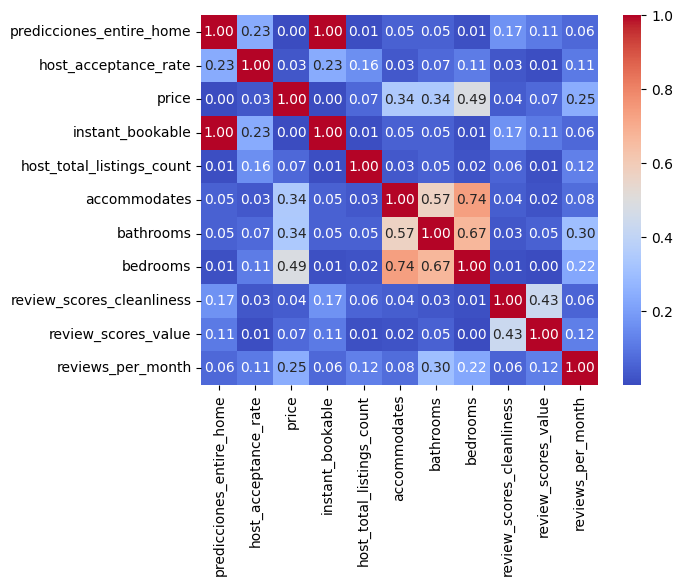

In [42]:
Heat_map=sns.heatmap(Corr_Factors_entire_home1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map

PRIVATE ROOM 

In [43]:
private_room_dfB['instant_bookable'] = private_room_dfB['instant_bookable'].map({'t': 1, 'f': 0})


C:\Users\jesus\AppData\Local\Temp\ipykernel_23160\4066913139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  private_room_dfB['instant_bookable'] = private_room_dfB['instant_bookable'].map({'t': 1, 'f': 0})


In [44]:
Vars_Indep_private_room = private_room_dfB[['instant_bookable']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_private_room = private_room_dfB['price']

In [45]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [46]:
type(model)

sklearn.linear_model._base.LinearRegression

In [47]:
model.fit(X=Vars_Indep_private_room, y=Var_Dep_private_room)

LinearRegression()

In [48]:
model.__dict__


{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['instant_bookable'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([17.52927726]),
 'rank_': 1,
 'singular_': array([2.84747399]),
 'intercept_': np.float64(97.28957009345794)}

In [49]:
model.score(Vars_Indep_private_room,Var_Dep_private_room)


0.024681180304627737

In [50]:
y_pred_private_room=model.predict(X=private_room_dfB[['instant_bookable']])
y_pred_private_room

array([ 97.28957009, 114.81884735, 114.81884735,  97.28957009,
        97.28957009,  97.28957009,  97.28957009,  97.28957009,
        97.28957009,  97.28957009, 114.81884735,  97.28957009,
        97.28957009,  97.28957009,  97.28957009,  97.28957009,
        97.28957009,  97.28957009,  97.28957009,  97.28957009,
        97.28957009,  97.28957009,  97.28957009, 114.81884735,
       114.81884735, 114.81884735, 114.81884735, 114.81884735,
       114.81884735, 114.81884735,  97.28957009,  97.28957009,
        97.28957009,  97.28957009, 114.81884735, 114.81884735,
        97.28957009])

In [51]:
private_room_dfB.insert(0,'predicciones_private_room',y_pred_private_room)
private_room_dfB

,predicciones_private_room,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,price,instant_bookable,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
46,97.289570,0.95,f,t,Private room in home,Private room,89.000000,0,1.0,2.0,1.0,1,4.93,4.93,1.96
51,114.818847,1.00,t,t,Private room in home,Private room,65.000000,1,1.0,2.0,1.0,1,4.93,4.89,2.24
67,114.818847,0.99,f,t,Private room in home,Private room,55.000000,1,5.0,2.0,1.0,1,4.76,4.78,1.23
68,97.289570,0.98,t,t,Private room in home,Private room,70.000000,0,1.0,2.0,1.0,1,4.78,4.76,1.80
84,97.289570,0.99,t,f,Private room in home,Private room,69.000000,0,3.0,3.0,1.0,1,4.97,4.91,1.80
103,97.289570,0.95,f,t,Private room in home,Private room,119.000000,0,7.0,1.0,1.0,1,5.00,4.88,0.32
107,97.289570,0.92,t,t,Private room in home,Private room,166.000000,0,7.0,2.0,1.0,1,4.99,4.81,3.04
123,97.289570,1.00,f,t,Private room in home,Private room,88.000000,0,1.0,2.0,1.0,1,5.00,5.00,1.18
124,97.289570,0.99,t,f,Private room in townhouse,Private room,60.000000,0,1.0,2.0,1.0,1,4.97,4.88,3.50
243,97.289570,0.33,f,t,Private room in condo,Private room,98.000000,0,2.0,4.0,1.0,2,5.00,5.00,0.05


In [52]:
coef_Deter_private_room=model.score(X=Vars_Indep_private_room, y=Var_Dep_private_room)
coef_Deter_private_room

0.024681180304627737

In [53]:
coef_Correl_private_room=np.sqrt(coef_Deter_private_room)
coef_Correl_private_room

np.float64(0.15710245161876926)

In [54]:
import numpy as np

numeric_df_private_room = private_room_dfB.select_dtypes(include=[np.number])
Corr_Factors_private_room = numeric_df_private_room.corr()
print(Corr_Factors_private_room)

                           predicciones_private_room  host_acceptance_rate  \
predicciones_private_room                   1.000000              0.201398   
host_acceptance_rate                        0.201398              1.000000   
price                                       0.157102              0.160857   
instant_bookable                            1.000000              0.201398   
host_total_listings_count                   0.163243             -0.007865   
accommodates                                0.357029             -0.138329   
bathrooms                                   0.013877              0.164946   
bedrooms                                   -0.055277             -0.422520   
review_scores_cleanliness                  -0.235349             -0.125866   
review_scores_value                        -0.166665             -0.206179   
reviews_per_month                           0.056867              0.265389   

                              price  instant_bookable  \
predic

In [55]:
Corr_Factors_private_room1=abs(Corr_Factors_private_room)
Corr_Factors_private_room1

,predicciones_private_room,host_acceptance_rate,price,instant_bookable,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
predicciones_private_room,1.000000,0.201398,0.157102,1.000000,0.163243,0.357029,0.013877,0.055277,0.235349,0.166665,0.056867
host_acceptance_rate,0.201398,1.000000,0.160857,0.201398,0.007865,0.138329,0.164946,0.422520,0.125866,0.206179,0.265389
price,0.157102,0.160857,1.000000,0.157102,0.202552,0.603021,0.639410,0.234149,0.161329,0.015351,0.250306
instant_bookable,1.000000,0.201398,0.157102,1.000000,0.163243,0.357029,0.013877,0.055277,0.235349,0.166665,0.056867
host_total_listings_count,0.163243,0.007865,0.202552,0.163243,1.000000,0.161619,0.095294,0.102001,0.027471,0.159937,0.207121
accommodates,0.357029,0.138329,0.603021,0.357029,0.161619,1.000000,0.339236,0.511329,0.039754,0.026498,0.244351
bathrooms,0.013877,0.164946,0.639410,0.013877,0.095294,0.339236,1.000000,0.090450,0.019132,0.237169,0.295134
bedrooms,0.055277,0.422520,0.234149,0.055277,0.102001,0.511329,0.090450,1.000000,0.113742,0.045017,0.348869
review_scores_cleanliness,0.235349,0.125866,0.161329,0.235349,0.027471,0.039754,0.019132,0.113742,1.000000,0.633835,0.004701
review_scores_value,0.166665,0.206179,0.015351,0.166665,0.159937,0.026498,0.237169,0.045017,0.633835,1.000000,0.084261


<Axes: >

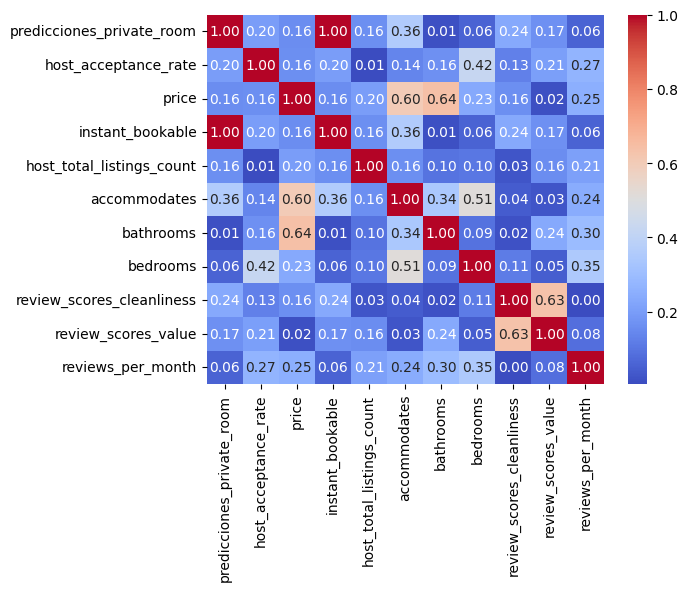

In [56]:
Heat_map=sns.heatmap(Corr_Factors_private_room1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map

<Axes: xlabel='instant_bookable', ylabel='price'>

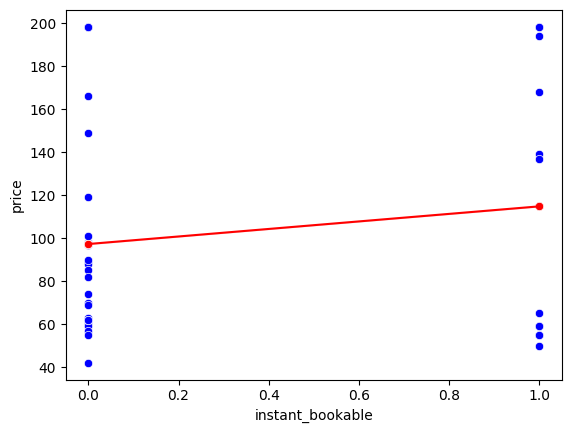

In [57]:
sns.scatterplot(x='instant_bookable',y='price',color="blue",data=private_room_dfB)
sns.scatterplot(x='instant_bookable',y='predicciones_private_room',color="red",data=private_room_dfB)
sns.lineplot(x='instant_bookable',y='predicciones_private_room',color="red",data=private_room_dfB)

SHARED ROOM

In [58]:
shared_room_dfB['instant_bookable'] =shared_room_dfB['instant_bookable'].map({'t': 1, 'f': 0})


C:\Users\jesus\AppData\Local\Temp\ipykernel_23160\2036591272.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shared_room_dfB['instant_bookable'] =shared_room_dfB['instant_bookable'].map({'t': 1, 'f': 0})


In [59]:
Vars_Indep_shared_room = shared_room_dfB[['instant_bookable']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_shared_room = shared_room_dfB['price']

In [60]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [61]:
type(model)

sklearn.linear_model._base.LinearRegression

In [62]:
model.fit(X=Vars_Indep_shared_room, y=Var_Dep_shared_room)

LinearRegression()

In [63]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['instant_bookable'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.]),
 'rank_': 0,
 'singular_': array([0.]),
 'intercept_': np.float64(40.0)}

In [64]:
model.score(Vars_Indep_shared_room,Var_Dep_shared_room)

c:\Users\jesus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [66]:
y_pred_shared_room=model.predict(X=shared_room_dfB[['instant_bookable']])
y_pred_shared_room

array([40.])

In [67]:
shared_room_dfB.insert(0,'predicciones_shared_room',y_pred_shared_room)
shared_room_dfB

,predicciones_shared_room,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,price,instant_bookable,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
31,40.0,0.99,f,t,Shared room in hostel,Shared room,40.0,1,5.0,3.0,2.5,1,4.9,4.7,0.94


In [68]:
coef_Deter_shared_room=model.score(X=Vars_Indep_shared_room, y=Var_Dep_shared_room)
coef_Deter_shared_room


c:\Users\jesus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [69]:
coef_Correl_shared_room=np.sqrt(coef_Deter_shared_room)
coef_Correl_shared_room

np.float64(nan)

In [ ]:
import numpy as np

numeric_df_shared_room = shared_room_dfB.select_dtypes(include=[np.number])
Corr_Factors_shared_room = numeric_df_shared_room.corr()
print(Corr_Factors_hotel_room)

                           predicciones_hotel_room  host_acceptance_rate  \
predicciones_hotel_room                   1.000000                   NaN   
host_acceptance_rate                           NaN                   NaN   
price                                     0.400197                   NaN   
host_total_listings_count                      NaN                   NaN   
accommodates                             -0.225494                   NaN   
bathrooms                                      NaN                   NaN   
bedrooms                                       NaN                   NaN   
review_scores_cleanliness                      NaN                   NaN   
review_scores_value                      -0.548860                   NaN   
reviews_per_month                         0.091695                   NaN   

                              price  host_total_listings_count  accommodates  \
predicciones_hotel_room    0.400197                        NaN     -0.225494   
hos

In [71]:

Corr_Factors_shared_room1=abs(Corr_Factors_shared_room)
Corr_Factors_shared_room1

,predicciones_hotel_room,host_acceptance_rate,price,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
predicciones_hotel_room,1.000000,NaN,0.400197,NaN,0.225494,NaN,NaN,NaN,0.548860,0.091695
host_acceptance_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,0.400197,NaN,1.000000,NaN,0.757247,NaN,NaN,NaN,0.262260,0.870782
host_total_listings_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,0.225494,NaN,0.757247,NaN,1.000000,NaN,NaN,NaN,0.161846,0.768063
bathrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_cleanliness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_value,0.548860,NaN,0.262260,NaN,0.161846,NaN,NaN,NaN,1.000000,0.502806
reviews_per_month,0.091695,NaN,0.870782,NaN,0.768063,NaN,NaN,NaN,0.502806,1.000000


<Axes: xlabel='instant_bookable', ylabel='price'>

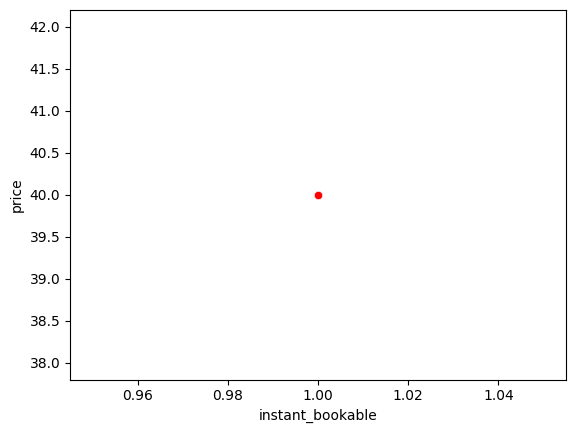

In [72]:
sns.scatterplot(x='instant_bookable',y='price',color="blue",data=shared_room_dfB)
sns.scatterplot(x='instant_bookable',y='predicciones_shared_room',color="red",data=shared_room_dfB)
sns.lineplot(x='instant_bookable',y='predicciones_shared_room',color="red",data=shared_room_dfB)

<Axes: >

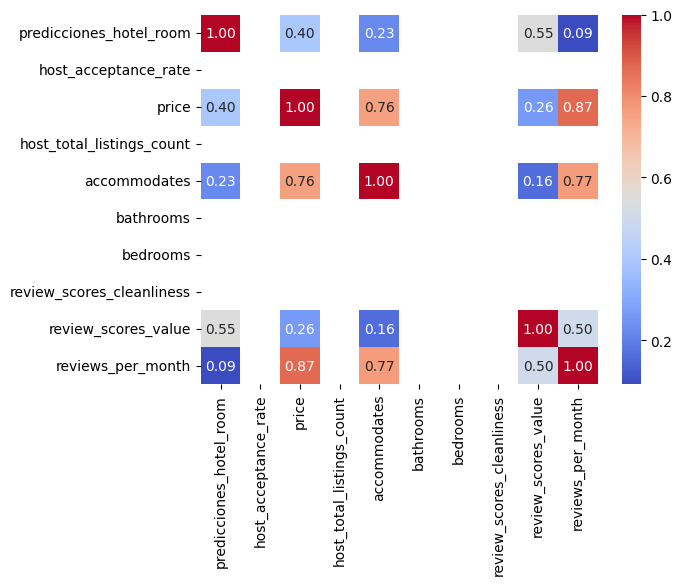

In [73]:
Heat_map=sns.heatmap(Corr_Factors_shared_room1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map

In [94]:
dfM=pd.read_csv('Datos_limpios_Mexico.csv')
dfM=dfM.drop('Unnamed: 0',axis=1)
dfM.head()
dfM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26582 entries, 0 to 26581
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   last_scraped                    26582 non-null  object 
 1   source                          26582 non-null  object 
 2   name                            26582 non-null  object 
 3   description                     26582 non-null  object 
 4   host_name                       26582 non-null  object 
 5   host_since                      26582 non-null  object 
 6   host_location                   26582 non-null  object 
 7   host_about                      26582 non-null  object 
 8   host_response_time              26582 non-null  object 
 9   host_response_rate              26582 non-null  object 
 10  host_acceptance_rate            26582 non-null  object 
 11  host_is_superhost               26582 non-null  object 
 12  host_verifications              

In [95]:
hotel_room_dfM = dfM[dfM['room_type'] == 'Hotel room']
entire_home_dfM = dfM[dfM['room_type'] == 'Entire home/apt']
private_room_dfM = dfM[dfM['room_type'] == 'Private room']
shared_room_dfM = dfM[dfM['room_type'] == 'Shared room'] 

<Axes: xlabel='room_type', ylabel='price'>

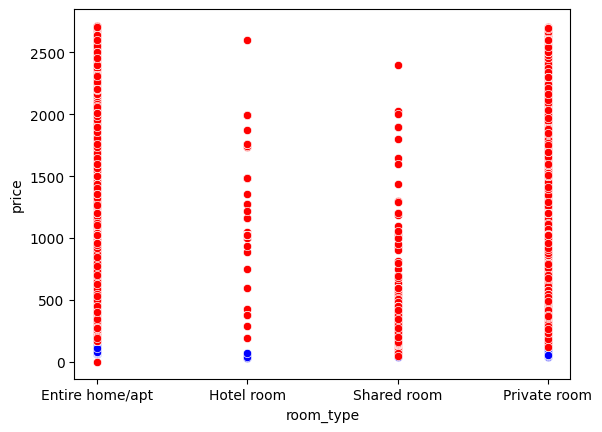

In [ ]:
#comparadno mexico con bozeman
sns.scatterplot(x='room_type', y='price', color='blue', data=dfB)
sns.scatterplot(x='room_type', y='price', color='red', data=dfM)

In [ ]:
sns.scatterplot(x='room_type', y='price', color='blue', data=dfB)
sns.scatterplot(x='room_type', y='price', color='red', data=dfM)